<a href="https://colab.research.google.com/github/Liuchenxi1/HCAStockPerformanceByTensorflowPridiction/blob/main/HCA_TensorFlow_Forecast_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HCA Healthcare Price Forecast — Clean TensorFlow Showcase

This notebook builds one clean modeling pipeline for **HCA Healthcare (HCA)** and compares:

1. `LinearRegression`
2. `Ridge`
3. a TensorFlow/Keras neural network

The final output converts predicted returns into **HCA price estimates and empirical forecast ranges** for approximately the end of **2026** and **2027**.

> This is an educational historical modeling exercise, not investment advice. The forecast ranges are based on historical model errors and are not guarantees.

In [1]:
!pip install -q yfinance pandas numpy matplotlib requests scikit-learn tensorflow

## 1. Imports and project settings

In [2]:
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from datetime import date

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

pd.set_option("display.max_columns", 100)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TICKER = "HCA"

MARKET_TICKERS = [
    "HCA",
    "XLV",
    "^VIX",
    "^IRX",
    "^TNX",
]

END_DATE = pd.Timestamp.today().normalize()
START_DATE = END_DATE - pd.DateOffset(years=10)

print("Start:", START_DATE.date())
print("End:  ", END_DATE.date())

Start: 2016-08-20
End:   2026-08-20


## 2. Download market data

`yfinance` returns a two-level column index when several tickers are downloaded.  
We intentionally **keep** that MultiIndex so `(field, ticker)` remains unambiguous.

In [3]:
market = yf.download(
    MARKET_TICKERS,
    start=START_DATE.strftime("%Y-%m-%d"),
    end=(END_DATE + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
    interval="1d",
    auto_adjust=False,
    progress=False,
    group_by="column",
)

if isinstance(market.columns, pd.MultiIndex):
    market.columns.names = ["Price", "Ticker"]

market = market.sort_index()

print("Rows:", len(market))
print("Column levels:", market.columns.names)

if isinstance(market.columns, pd.MultiIndex):
    print("Tickers:", market.columns.get_level_values("Ticker").unique().tolist())

market.tail()

Rows: 2514
Column levels: ['Price', 'Ticker']
Tickers: ['HCA', 'XLV', '^IRX', '^TNX', '^VIX']


Price        Adj Close                                        Close  \
Ticker             HCA         XLV   ^IRX   ^TNX   ^VIX         HCA   
Date                                                                  
2026-08-14  404.679993  167.369995  3.697  4.696  14.25  404.679993   
2026-08-17  404.980011  167.050003  3.703  4.724  15.19  404.980011   
2026-08-18  411.730011  169.729996  3.705  4.706  15.84  411.730011   
2026-08-19  407.049988  175.679993  3.700  4.653  14.89  407.049988   
2026-08-20  406.355011  172.660004  3.703  4.696  16.02  406.355011   

Price                                              High                     \
Ticker             XLV   ^IRX   ^TNX   ^VIX         HCA         XLV   ^IRX   
Date                                                                         
2026-08-14  167.369995  3.697  4.696  14.25  412.690002  167.770004  3.700   
2026-08-17  167.050003  3.703  4.724  15.19  407.320007  167.869995  3.705   
2026-08-18  169.729996  3.705  4.706  15.84  417.989990  170.300003  3.713   
2026-08-19  175.679993  3.700  4.653  14.89  422.000000  176.600006  3.707   
2026-08-20  172.660004  3.703  4.696  16.02  411.140015  175.190002  3.705   

Price                                Low                                   \
Ticker       ^TNX       ^VIX         HCA         XLV   ^IRX   ^TNX   ^VIX   
Date                                                                        
2026-08-14  4.700  14.720000  403.779999  166.449997  3.695  4.625  14.18   
2026-08-17  4.728  15.470000  400.000000  165.860001  3.695  4.692  14.89   
2026-08-18  4.746  16.090000  406.149994  168.449997  3.705  4.704  15.60   
2026-08-19  4.684  15.950000  406.809998  172.289993  3.697  4.637  14.77   
2026-08-20  4.714  16.139999  403.390015  172.360001  3.697  4.674  14.91   

Price             Open                                      Volume  \
Ticker             HCA         XLV   ^IRX   ^TNX   ^VIX        HCA   
Date                                                                 
2026-08-14  410.459991  167.660004  3.697  4.645  14.64   936700.0   
2026-08-17  401.000000  166.449997  3.695  4.694  14.98  1005600.0   
2026-08-18  409.049988  168.669998  3.710  4.732  15.81  1450000.0   
2026-08-19  411.079987  172.470001  3.700  4.684  15.92  1436600.0   
2026-08-20  403.350006  174.190002  3.700  4.706  14.91   708739.0   

Price                                  
Ticker             XLV ^IRX ^TNX ^VIX  
Date                                   
2026-08-14   5023800.0  0.0  0.0    0  
2026-08-17   7225500.0  0.0  0.0    0  
2026-08-18   7529600.0  0.0  0.0    0  
2026-08-19  16538900.0  0.0  0.0    0  
2026-08-20   8090805.0  0.0  0.0    0

## 3. Build the clean modeling DataFrame

`market` remains the raw MultiIndex dataset.  
`df` is a separate, **single-level** modeling table. This avoids the earlier merge errors.

In [4]:
def get_ticker_column(data, field, ticker):
    if isinstance(data.columns, pd.MultiIndex):
        return data[field][ticker]
    return data[field]


df = pd.DataFrame(index=market.index.copy())
df.index.name = "Date"

# HCA
df["HCA_Open"] = get_ticker_column(market, "Open", "HCA")
df["HCA_High"] = get_ticker_column(market, "High", "HCA")
df["HCA_Low"] = get_ticker_column(market, "Low", "HCA")
df["HCA_Close"] = get_ticker_column(market, "Close", "HCA")
df["HCA_Adj_Close"] = get_ticker_column(market, "Adj Close", "HCA")
df["HCA_Volume"] = get_ticker_column(market, "Volume", "HCA")

# Sector / macro market variables
df["XLV_Close"] = get_ticker_column(market, "Close", "XLV")
df["VIX"] = get_ticker_column(market, "Close", "^VIX")
df["Treasury_3M"] = get_ticker_column(market, "Close", "^IRX")
df["Treasury_10Y"] = get_ticker_column(market, "Close", "^TNX")

# Returns / changes
df["HCA_Return_1D"] = df["HCA_Adj_Close"].pct_change()
df["XLV_Return_1D"] = df["XLV_Close"].pct_change()
df["VIX_Change"] = df["VIX"].pct_change()
df["Treasury_3M_Change"] = df["Treasury_3M"].diff()
df["Treasury_10Y_Change"] = df["Treasury_10Y"].diff()
df["Yield_Curve_10Y_3M"] = df["Treasury_10Y"] - df["Treasury_3M"]

print("df column levels:", df.columns.nlevels)
print("df shape:", df.shape)
df.tail()

df column levels: 1
df shape: (2514, 16)


/tmp/ipykernel_2195/1325613587.py:25: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["HCA_Return_1D"] = df["HCA_Adj_Close"].pct_change()
/tmp/ipykernel_2195/1325613587.py:26: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["XLV_Return_1D"] = df["XLV_Close"].pct_change()


,HCA_Open,HCA_High,HCA_Low,HCA_Close,HCA_Adj_Close,HCA_Volume,XLV_Close,VIX,Treasury_3M,Treasury_10Y,HCA_Return_1D,XLV_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M
Date,,,,,,,,,,,,,,,,
2026-08-14,410.459991,412.690002,403.779999,404.679993,404.679993,936700.0,167.369995,14.25,3.697,4.696,-0.017147,-0.005998,-0.025974,-0.008,0.055,0.999
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,167.050003,15.19,3.703,4.724,0.000741,-0.001912,0.065965,0.006,0.028,1.021
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,169.729996,15.84,3.705,4.706,0.016667,0.016043,0.042791,0.002,-0.018,1.001
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,175.679993,14.89,3.700,4.653,-0.011367,0.035056,-0.059975,-0.005,-0.053,0.953
2026-08-20,403.350006,411.140015,403.390015,406.355011,406.355011,708739.0,172.660004,16.02,3.703,4.696,-0.001707,-0.017190,0.075890,0.003,0.043,0.993


## 4. Money-flow and technical features

In [5]:
# Money flow
df["Typical_Price"] = (
    df["HCA_High"] + df["HCA_Low"] + df["HCA_Close"]
) / 3

df["Dollar_Volume"] = df["Typical_Price"] * df["HCA_Volume"]

price_range = (df["HCA_High"] - df["HCA_Low"]).replace(0, np.nan)

df["Money_Flow_Multiplier"] = (
    ((df["HCA_Close"] - df["HCA_Low"]) -
     (df["HCA_High"] - df["HCA_Close"]))
    / price_range
)

df["Money_Flow_Volume"] = (
    df["Money_Flow_Multiplier"] * df["HCA_Volume"]
)

df["Directional_Dollar_Flow"] = (
    df["Money_Flow_Multiplier"] * df["Dollar_Volume"]
)

for window in [5, 20, 60]:
    df[f"Flow_{window}D"] = (
        df["Directional_Dollar_Flow"].rolling(window).sum()
    )

# Moving averages
for window in [20, 50, 200]:
    df[f"MA_{window}"] = df["HCA_Adj_Close"].rolling(window).mean()

# RSI
delta = df["HCA_Adj_Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss.replace(0, np.nan)

df["RSI_14"] = 100 - (100 / (1 + rs))

# MACD
ema_12 = df["HCA_Adj_Close"].ewm(span=12, adjust=False).mean()
ema_26 = df["HCA_Adj_Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema_12 - ema_26
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Volatility
df["Volatility_20D"] = df["HCA_Return_1D"].rolling(20).std()
df["Volatility_60D"] = df["HCA_Return_1D"].rolling(60).std()

df.tail()

,HCA_Open,HCA_High,HCA_Low,HCA_Close,HCA_Adj_Close,HCA_Volume,XLV_Close,VIX,Treasury_3M,Treasury_10Y,HCA_Return_1D,XLV_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M,Typical_Price,Dollar_Volume,Money_Flow_Multiplier,Money_Flow_Volume,Directional_Dollar_Flow,Flow_5D,Flow_20D,Flow_60D,MA_20,MA_50,MA_200,RSI_14,MACD,MACD_Signal,Volatility_20D,Volatility_60D
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-14,410.459991,412.690002,403.779999,404.679993,404.679993,936700.0,167.369995,14.25,3.697,4.696,-0.017147,-0.005998,-0.025974,-0.008,0.055,0.999,407.049998,3.812837e+08,-0.797981,-7.474690e+05,-3.042573e+08,-6.800638e+07,8.802385e+08,NaN,399.20750,392.206823,NaN,57.674280,5.410906,4.628414,0.021702,0.022833
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,167.050003,15.19,3.703,4.724,0.000741,-0.001912,0.065965,0.006,0.028,1.021,404.100006,4.063630e+08,0.360657,3.626771e+05,1.465578e+08,-1.098997e+08,1.276782e+09,NaN,400.93550,393.084298,NaN,40.544022,4.855487,4.673828,0.021666,0.022788
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,169.729996,15.84,3.705,4.706,0.016667,0.016043,0.042791,0.002,-0.018,1.001,411.956665,5.973372e+08,-0.057429,-8.327242e+04,-3.430463e+07,1.560580e+08,8.797972e+08,NaN,402.86750,393.891185,NaN,52.665582,4.903458,4.719754,0.021827,0.022877
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,175.679993,14.89,3.700,4.653,-0.011367,0.035056,-0.059975,-0.005,-0.053,0.953,411.953328,5.918122e+08,-0.968402,-1.391206e+06,-5.731118e+08,-6.661333e+08,5.633129e+08,-2.103794e+08,404.62650,394.820238,NaN,59.561807,4.511827,4.678169,0.022065,0.022932
2026-08-20,403.350006,411.140015,403.390015,406.355011,406.355011,708739.0,172.660004,16.02,3.703,4.696,-0.001707,-0.017190,0.075890,0.003,0.043,0.993,406.961680,2.884296e+08,-0.234840,-1.664400e+05,-6.773471e+07,-8.328506e+08,1.768163e+08,-3.700480e+08,406.11925,395.464335,NaN,53.567046,4.098137,4.562163,0.022033,0.022925


## 5. SEC fundamentals

HCA Healthcare's correct SEC CIK is **0000860730**.

Fundamentals are merged by **filing date**, not period-end date, so the model only sees information after it became publicly available.

In [6]:
HCA_CIK = "0000860730"

SEC_URL = (
    "https://data.sec.gov/api/xbrl/companyfacts/"
    f"CIK{HCA_CIK}.json"
)

# SEC asks automated clients to identify themselves.
# Replace the example email with your own contact email if you publish/run this heavily.
headers = {
    "User-Agent": "HCA TensorFlow research example research@example.com"
}

response = requests.get(
    SEC_URL,
    headers=headers,
    timeout=30,
)
response.raise_for_status()

sec_data = response.json()

print("Company:", sec_data.get("entityName"))
print("CIK:", sec_data.get("cik"))

facts = sec_data["facts"]["us-gaap"]
print("US-GAAP concepts:", len(facts))

Company: HCA Healthcare, Inc.
CIK: 860730
US-GAAP concepts: 469


In [7]:
def get_sec_fact(concept, unit="USD", forms=("10-Q", "10-K")):
    if concept not in facts:
        return pd.DataFrame()

    concept_data = facts[concept]

    if "units" not in concept_data:
        return pd.DataFrame()

    if unit not in concept_data["units"]:
        available_units = list(concept_data["units"].keys())
        if not available_units:
            return pd.DataFrame()
        unit = available_units[0]

    rows = []

    for item in concept_data["units"][unit]:
        if item.get("form") not in forms:
            continue

        rows.append({
            "start": item.get("start"),
            "end": item.get("end"),
            "filed": item.get("filed"),
            "form": item.get("form"),
            "fy": item.get("fy"),
            "fp": item.get("fp"),
            "value": item.get("val"),
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    for col in ["start", "end", "filed"]:
        if col in result.columns:
            result[col] = pd.to_datetime(result[col])

    return result.sort_values(["filed", "end"])


def first_available_fact(concepts):
    for concept in concepts:
        table = get_sec_fact(concept)
        if not table.empty:
            return concept, table
    return None, pd.DataFrame()


def prepare_fundamental_table(table, column_name):
    x = table.copy()

    x = x.rename(columns={"filed": "Available_Date"})
    x = x[["Available_Date", "end", column_name]].dropna()

    # On the same filing date, keep the observation with the latest period end.
    x = (
        x.sort_values(["Available_Date", "end"])
         .drop_duplicates("Available_Date", keep="last")
         [["Available_Date", column_name]]
    )

    return x


def merge_point_in_time(left, right):
    left_work = left.reset_index().sort_values("Date")
    right_work = right.sort_values("Available_Date")

    merged = pd.merge_asof(
        left_work,
        right_work,
        left_on="Date",
        right_on="Available_Date",
        direction="backward",
    )

    merged = (
        merged
        .drop(columns=["Available_Date"], errors="ignore")
        .set_index("Date")
    )

    return merged

In [8]:
# Try common SEC concept alternatives because issuers do not all use
# exactly the same XBRL tag for the same economic item.

concept_options = {
    "Total_Assets": [
        "Assets"
    ],
    "Total_Liabilities": [
        "Liabilities"
    ],
    "Cash": [
        "CashAndCashEquivalentsAtCarryingValue",
        "CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents"
    ],
    "Stockholders_Equity": [
        "StockholdersEquity",
        "StockholdersEquityIncludingPortionAttributableToNoncontrollingInterest"
    ],
    "Revenue": [
        "RevenueFromContractWithCustomerExcludingAssessedTax",
        "Revenues"
    ],
    "Net_Income": [
        "NetIncomeLoss"
    ],
    "Operating_Cash_Flow": [
        "NetCashProvidedByUsedInOperatingActivities"
    ],
    "Capital_Expenditures": [
        "PaymentsToAcquirePropertyPlantAndEquipment"
    ],
}

fundamental_tables = {}

for name, candidates in concept_options.items():
    concept, table = first_available_fact(candidates)

    if table.empty:
        print(f"{name}: NOT FOUND")
        continue

    table = table.rename(columns={"value": name})
    fundamental_tables[name] = prepare_fundamental_table(table, name)

    print(
        f"{name}: {concept} "
        f"({len(fundamental_tables[name])} filing observations)"
    )

for name, table in fundamental_tables.items():
    df = merge_point_in_time(df, table)

print("\nAfter fundamental merge:", df.shape)

Total_Assets: Assets (61 filing observations)
Total_Liabilities: Liabilities (32 filing observations)
Cash: CashAndCashEquivalentsAtCarryingValue (61 filing observations)
Stockholders_Equity: StockholdersEquity (61 filing observations)
Revenue: Revenues (18 filing observations)
Net_Income: NetIncomeLoss (61 filing observations)
Operating_Cash_Flow: NetCashProvidedByUsedInOperatingActivities (46 filing observations)
Capital_Expenditures: PaymentsToAcquirePropertyPlantAndEquipment (61 filing observations)

After fundamental merge: (2514, 40)


## 6. Debt, free cash flow, ratios, and growth

Debt is built **before** debt ratios, so the old duplicate/out-of-order ratio cells are no longer needed.

In [9]:
# Prefer current + noncurrent debt components.
debt_component_options = {
    "Debt_Current": [
        "LongTermDebtAndFinanceLeaseObligationsCurrent",
        "LongTermDebtCurrent"
    ],
    "Debt_Noncurrent": [
        "LongTermDebtAndFinanceLeaseObligationsNoncurrent",
        "LongTermDebtNoncurrent"
    ],
}

debt_found = []

for name, candidates in debt_component_options.items():
    concept, table = first_available_fact(candidates)

    if not table.empty:
        table = table.rename(columns={"value": name})
        table = prepare_fundamental_table(table, name)
        df = merge_point_in_time(df, table)
        debt_found.append(name)
        print(f"{name}: {concept}")

if debt_found:
    df["Total_Debt"] = df[debt_found].sum(axis=1, min_count=1)
else:
    # Fallback if HCA reports only a combined debt tag.
    concept, table = first_available_fact(["LongTermDebt"])

    if not table.empty:
        table = table.rename(columns={"value": "Total_Debt"})
        table = prepare_fundamental_table(table, "Total_Debt")
        df = merge_point_in_time(df, table)
        print("Total_Debt fallback:", concept)
    else:
        df["Total_Debt"] = np.nan
        print("WARNING: No debt concept found.")

# Free cash flow
df["Free_Cash_Flow"] = (
    df["Operating_Cash_Flow"] -
    df["Capital_Expenditures"].abs()
)

# Ratios, protected against zero denominators
df["Debt_to_Assets"] = (
    df["Total_Debt"] /
    df["Total_Assets"].replace(0, np.nan)
)

df["Cash_to_Debt"] = (
    df["Cash"] /
    df["Total_Debt"].replace(0, np.nan)
)

df["FCF_Margin"] = (
    df["Free_Cash_Flow"] /
    df["Revenue"].replace(0, np.nan)
)

# Growth features.
# Because fundamentals are point-in-time forward-filled into daily rows,
# these are mostly zero between filing updates and change on update dates.
for new_col, source_col in {
    "Revenue_Growth": "Revenue",
    "Net_Income_Growth": "Net_Income",
    "Asset_Growth": "Total_Assets",
    "Liability_Growth": "Total_Liabilities",
    "FCF_Growth": "Free_Cash_Flow",
}.items():
    df[new_col] = df[source_col].pct_change(fill_method=None)

df = df.replace([np.inf, -np.inf], np.nan).sort_index()

print(df.shape)
df.tail()

Debt_Current: LongTermDebtCurrent
Debt_Noncurrent: LongTermDebtNoncurrent
(2514, 52)


,HCA_Open,HCA_High,HCA_Low,HCA_Close,HCA_Adj_Close,HCA_Volume,XLV_Close,VIX,Treasury_3M,Treasury_10Y,HCA_Return_1D,XLV_Return_1D,VIX_Change,Treasury_3M_Change,Treasury_10Y_Change,Yield_Curve_10Y_3M,Typical_Price,Dollar_Volume,Money_Flow_Multiplier,Money_Flow_Volume,Directional_Dollar_Flow,Flow_5D,Flow_20D,Flow_60D,MA_20,MA_50,MA_200,RSI_14,MACD,MACD_Signal,Volatility_20D,Volatility_60D,Total_Assets,Total_Liabilities,Cash,Stockholders_Equity,Revenue,Net_Income,Operating_Cash_Flow,Capital_Expenditures,Debt_Current,Debt_Noncurrent,Total_Debt,Free_Cash_Flow,Debt_to_Assets,Cash_to_Debt,FCF_Margin,Revenue_Growth,Net_Income_Growth,Asset_Growth,Liability_Growth,FCF_Growth
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-14,410.459991,412.690002,403.779999,404.679993,404.679993,936700.0,167.369995,14.25,3.697,4.696,-0.017147,-0.005998,-0.025974,-0.008,0.055,0.999,407.049998,3.812837e+08,-0.797981,-7.474690e+05,-3.042573e+08,-6.800638e+07,8.802385e+08,NaN,399.20750,392.206823,NaN,57.674280,5.410906,4.628414,0.021702,0.022833,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-17,401.000000,407.320007,400.000000,404.980011,404.980011,1005600.0,167.050003,15.19,3.703,4.724,0.000741,-0.001912,0.065965,0.006,0.028,1.021,404.100006,4.063630e+08,0.360657,3.626771e+05,1.465578e+08,-1.098997e+08,1.276782e+09,NaN,400.93550,393.084298,NaN,40.544022,4.855487,4.673828,0.021666,0.022788,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-18,409.049988,417.989990,406.149994,411.730011,411.730011,1450000.0,169.729996,15.84,3.705,4.706,0.016667,0.016043,0.042791,0.002,-0.018,1.001,411.956665,5.973372e+08,-0.057429,-8.327242e+04,-3.430463e+07,1.560580e+08,8.797972e+08,NaN,402.86750,393.891185,NaN,52.665582,4.903458,4.719754,0.021827,0.022877,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-19,411.079987,422.000000,406.809998,407.049988,407.049988,1436600.0,175.679993,14.89,3.700,4.653,-0.011367,0.035056,-0.059975,-0.005,-0.053,0.953,411.953328,5.918122e+08,-0.968402,-1.391206e+06,-5.731118e+08,-6.661333e+08,5.633129e+08,-2.103794e+08,404.62650,394.820238,NaN,59.561807,4.511827,4.678169,0.022065,0.022932,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0
2026-08-20,403.350006,411.140015,403.390015,406.355011,406.355011,708739.0,172.660004,16.02,3.703,4.696,-0.001707,-0.017190,0.075890,0.003,0.043,0.993,406.961680,2.884296e+08,-0.234840,-1.664400e+05,-6.773471e+07,-8.328506e+08,1.768163e+08,-3.700480e+08,406.11925,395.464335,NaN,53.567046,4.098137,4.562163,0.022033,0.022925,61450000000,45623000000,940000000,-6303000000,1.910900e+10,1620000000,2014000000,1119000000,3519000000,39491000000,43010000000,895000000,0.699919,0.021855,0.046837,0.0,0.0,0.0,0.0,0.0


## 7. Features and forecast horizons

The latest available row is used for the real forecast.

The two target horizons are calculated from the latest observation to:

- **December 31, 2026**
- **December 31, 2027**

For historical training, the same number of trading-day steps is applied to older observations.

In [10]:
FEATURES = [
    # HCA market
    "HCA_Adj_Close",
    "HCA_Volume",
    "HCA_Return_1D",

    # Trading / money flow
    "Dollar_Volume",
    "Money_Flow_Multiplier",
    "Money_Flow_Volume",
    "Directional_Dollar_Flow",
    "Flow_5D",
    "Flow_20D",
    "Flow_60D",

    # Technical
    "MA_20",
    "MA_50",
    "MA_200",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "Volatility_20D",
    "Volatility_60D",

    # Sector / market
    "XLV_Close",
    "XLV_Return_1D",
    "VIX",
    "VIX_Change",

    # Rates
    "Treasury_3M",
    "Treasury_10Y",
    "Treasury_3M_Change",
    "Treasury_10Y_Change",
    "Yield_Curve_10Y_3M",

    # Fundamentals
    "Total_Assets",
    "Total_Liabilities",
    "Cash",
    "Total_Debt",
    "Stockholders_Equity",
    "Revenue",
    "Net_Income",
    "Operating_Cash_Flow",
    "Capital_Expenditures",
    "Free_Cash_Flow",

    # Ratios
    "Debt_to_Assets",
    "Cash_to_Debt",
    "FCF_Margin",

    # Growth
    "Revenue_Growth",
    "Net_Income_Growth",
    "Asset_Growth",
    "Liability_Growth",
    "FCF_Growth",
]

available_features = [x for x in FEATURES if x in df.columns]
missing_features = [x for x in FEATURES if x not in df.columns]

print("Features available:", len(available_features))

if missing_features:
    print("Missing:", missing_features)

# The latest row with every model feature present
latest_features = df[available_features].dropna().iloc[[-1]].copy()
latest_date = latest_features.index[-1]
latest_hca_price = float(df.loc[latest_date, "HCA_Adj_Close"])

print("\nLatest usable feature date:", latest_date.date())
print(f"Latest HCA adjusted close: ${latest_hca_price:,.2f}")

TARGET_DATES = {
    "End_2026": pd.Timestamp("2026-12-31"),
    "End_2027": pd.Timestamp("2027-12-31"),
}

HORIZONS = {}

for name, target_date in TARGET_DATES.items():
    # Weekday count is a practical approximation to trading days.
    # The shift below operates on actual rows in the downloaded market data.
    business_days = np.busday_count(
        latest_date.date(),
        target_date.date()
    )

    HORIZONS[name] = max(int(business_days), 1)

print("\nForecast horizons:", HORIZONS)

for name, horizon in HORIZONS.items():
    target_col = f"Target_{name}_Return"

    df[target_col] = (
        df["HCA_Adj_Close"].shift(-horizon)
        / df["HCA_Adj_Close"]
        - 1
    )

Features available: 45

Latest usable feature date: 2026-05-22
Latest HCA adjusted close: $393.28

Forecast horizons: {'End_2026': 159, 'End_2027': 420}


## 8. Prepare chronological train / validation / test data

No random shuffle is used. The oldest observations train the models and the newest historical observations test them.

The same scaled data is then supplied to Linear Regression, Ridge, and TensorFlow for a fair comparison.

In [11]:
def prepare_horizon_dataset(name):
    target_col = f"Target_{name}_Return"

    model_data = (
        df[available_features + [target_col]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_index()
        .copy()
    )

    n = len(model_data)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train = model_data.iloc[:train_end]
    val = model_data.iloc[train_end:val_end]
    test = model_data.iloc[val_end:]

    X_train = train[available_features]
    y_train = train[target_col]

    X_val = val[available_features]
    y_val = val[target_col]

    X_test = test[available_features]
    y_test = test[target_col]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    latest_scaled = scaler.transform(latest_features[available_features])

    print(f"\n{name}")
    print("-" * 60)
    print(
        "Train:",
        X_train.index.min().date(),
        "->",
        X_train.index.max().date(),
        len(X_train),
    )
    print(
        "Validation:",
        X_val.index.min().date(),
        "->",
        X_val.index.max().date(),
        len(X_val),
    )
    print(
        "Test:",
        X_test.index.min().date(),
        "->",
        X_test.index.max().date(),
        len(X_test),
    )

    return {
        "name": name,
        "target": target_col,
        "model_data": model_data,
        "X_train": X_train,
        "X_val": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_val": y_val,
        "y_test": y_test,
        "X_train_scaled": X_train_scaled,
        "X_val_scaled": X_val_scaled,
        "X_test_scaled": X_test_scaled,
        "latest_scaled": latest_scaled,
        "scaler": scaler,
    }


datasets = {
    name: prepare_horizon_dataset(name)
    for name in HORIZONS
}


End_2026
------------------------------------------------------------
Train: 2022-02-22 -> 2024-10-31 678
Validation: 2024-11-01 -> 2025-06-03 145
Test: 2025-06-04 -> 2026-01-02 146

End_2027
------------------------------------------------------------
Train: 2022-02-22 -> 2024-02-09 495
Validation: 2024-02-12 -> 2024-07-15 106
Test: 2024-07-16 -> 2024-12-16 107


## 9. Linear Regression and Ridge baselines

In [12]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


baseline_models = {}
comparison_rows = []

for name, data in datasets.items():

    # Linear Regression
    linear = LinearRegression()
    linear.fit(
        data["X_train_scaled"],
        data["y_train"]
    )

    linear_pred = linear.predict(data["X_test_scaled"])
    linear_metrics = regression_metrics(data["y_test"], linear_pred)

    baseline_models[(name, "LinearRegression")] = linear

    comparison_rows.append({
        "Horizon": name,
        "Model": "LinearRegression",
        **linear_metrics,
    })

    # Ridge
    ridge = Ridge(alpha=1.0)
    ridge.fit(
        data["X_train_scaled"],
        data["y_train"]
    )

    ridge_pred = ridge.predict(data["X_test_scaled"])
    ridge_metrics = regression_metrics(data["y_test"], ridge_pred)

    baseline_models[(name, "Ridge")] = ridge

    comparison_rows.append({
        "Horizon": name,
        "Model": "Ridge",
        **ridge_metrics,
    })

baseline_results = pd.DataFrame(comparison_rows)
baseline_results

,Horizon,Model,MAE,RMSE,R2
0,End_2026,LinearRegression,2.756684,2.784430,-126.001584
1,End_2026,Ridge,0.493922,0.505541,-3.186481
2,End_2027,LinearRegression,0.797286,0.806236,-21.425405
3,End_2027,Ridge,0.474537,0.481375,-6.994343


## 10. TensorFlow neural network

This is the main showcase model. Early stopping uses the chronological validation period.

In [13]:
def build_tensorflow_model(n_features):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(n_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.20),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )

    return model


tf_models = {}
tf_histories = {}

for name, data in datasets.items():

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = build_tensorflow_model(
        data["X_train_scaled"].shape[1]
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
    )

    history = model.fit(
        data["X_train_scaled"],
        data["y_train"],
        validation_data=(
            data["X_val_scaled"],
            data["y_val"],
        ),
        epochs=300,
        batch_size=32,
        verbose=0,
        callbacks=[early_stopping],
    )

    tf_models[name] = model
    tf_histories[name] = history

    print(
        name,
        "- epochs:",
        len(history.history["loss"]),
        "- best val loss:",
        min(history.history["val_loss"]),
    )

End_2026 - epochs: 63 - best val loss: 0.0741446316242218
End_2027 - epochs: 48 - best val loss: 0.04082243889570236


## 11. Compare all three models

MAE (Mean Absolute Error): This metric measures the average magnitude of the errors in a set of predictions, without considering their direction. It's the average of the absolute differences between your model's predictions and the actual values. A lower MAE indicates a better model.

RMSE (Root Mean Squared Error): This is another measure of the average magnitude of error. It's the square root of the average of the squared differences between predictions and actual values. RMSE penalizes large errors more heavily than MAE due to the squaring of errors. Like MAE, a lower RMSE indicates a better model.

R² (R-squared) or Coefficient of Determination: This metric represents the proportion of the variance in the dependent variable that can be predicted from the independent variable(s) in the model. In simpler terms, it tells you how well your model explains the variability of the target variable. R² values range from 0 to 1, where 1 means the model perfectly explains the variance, and 0 means it explains none of the variance. However, a negative R² (as seen in your output for Linear Regression and Ridge) can occur when the model performs worse than simply predicting the mean of the target variable. A higher R² (closer to 1) generally indicates a better fit.

In [14]:
comparison_rows = []

for name, data in datasets.items():

    # Linear
    linear = baseline_models[(name, "LinearRegression")]
    pred = linear.predict(data["X_test_scaled"])

    comparison_rows.append({
        "Horizon": name,
        "Model": "LinearRegression",
        **regression_metrics(data["y_test"], pred),
    })

    # Ridge
    ridge = baseline_models[(name, "Ridge")]
    pred = ridge.predict(data["X_test_scaled"])

    comparison_rows.append({
        "Horizon": name,
        "Model": "Ridge",
        **regression_metrics(data["y_test"], pred),
    })

    # TensorFlow
    model = tf_models[name]
    pred = model.predict(
        data["X_test_scaled"],
        verbose=0
    ).reshape(-1)

    comparison_rows.append({
        "Horizon": name,
        "Model": "TensorFlow NN",
        **regression_metrics(data["y_test"], pred),
    })

comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["Horizon", "MAE"])
    .reset_index(drop=True)
)

comparison

,Horizon,Model,MAE,RMSE,R2
0,End_2026,TensorFlow NN,0.230522,0.266136,-0.160229
1,End_2026,Ridge,0.493922,0.505541,-3.186481
2,End_2026,LinearRegression,2.756684,2.784430,-126.001584
3,End_2027,TensorFlow NN,0.342138,0.376354,-3.886636
4,End_2027,Ridge,0.474537,0.481375,-6.994343
5,End_2027,LinearRegression,0.797286,0.806236,-21.425405


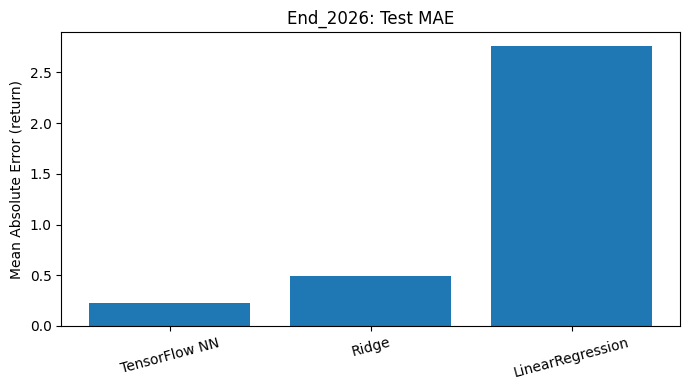

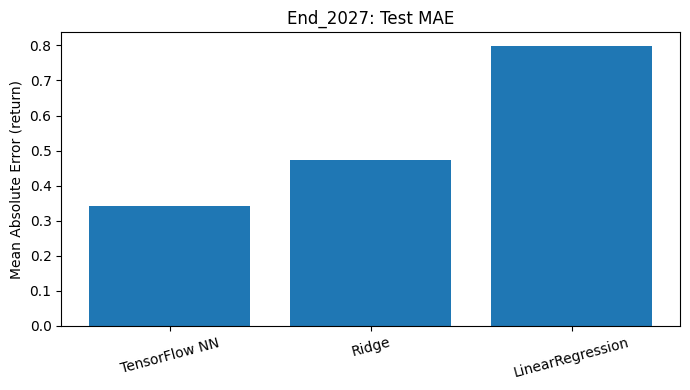

In [15]:
# Visual comparison: lower MAE is better
for horizon in comparison["Horizon"].unique():
    subset = comparison[comparison["Horizon"] == horizon]

    plt.figure(figsize=(7, 4))
    plt.bar(subset["Model"], subset["MAE"])
    plt.title(f"{horizon}: Test MAE")
    plt.ylabel("Mean Absolute Error (return)")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

## 12. Latest HCA forecasts and empirical price ranges

For each model:

- predict the future return from the latest available feature row;
- convert that return to a price;
- use the **10th and 90th percentiles of historical test residuals** to create an empirical range.

This is an error-based historical range, not a statistical guarantee.

In [16]:
forecast_rows = []

for name, data in datasets.items():

    target_date = TARGET_DATES[name]

    model_specs = [
        (
            "LinearRegression",
            baseline_models[(name, "LinearRegression")]
        ),
        (
            "Ridge",
            baseline_models[(name, "Ridge")]
        ),
        (
            "TensorFlow NN",
            tf_models[name]
        ),
    ]

    for model_name, model in model_specs:

        if model_name == "TensorFlow NN":
            test_pred = model.predict(
                data["X_test_scaled"],
                verbose=0
            ).reshape(-1)

            forecast_return = float(
                model.predict(
                    data["latest_scaled"],
                    verbose=0
                ).reshape(-1)[0]
            )

        else:
            test_pred = model.predict(data["X_test_scaled"])
            forecast_return = float(
                model.predict(data["latest_scaled"])[0]
            )

        residuals = data["y_test"].to_numpy() - test_pred

        residual_low = np.quantile(residuals, 0.10)
        residual_high = np.quantile(residuals, 0.90)

        return_low = forecast_return + residual_low
        return_high = forecast_return + residual_high

        central_price = latest_hca_price * (1 + forecast_return)
        low_price = max(
            0,
            latest_hca_price * (1 + return_low)
        )
        high_price = max(
            0,
            latest_hca_price * (1 + return_high)
        )

        forecast_rows.append({
            "Target_Date": target_date.date(),
            "Horizon": name,
            "Model": model_name,
            "Latest_Price": latest_hca_price,
            "Predicted_Return": forecast_return,
            "Forecast_Price": central_price,
            "Range_Low": min(low_price, high_price),
            "Range_High": max(low_price, high_price),
        })

forecast_table = pd.DataFrame(forecast_rows)

display(
    forecast_table.style.format({
        "Latest_Price": "${:,.2f}",
        "Predicted_Return": "{:.1%}",
        "Forecast_Price": "${:,.2f}",
        "Range_Low": "${:,.2f}",
        "Range_High": "${:,.2f}",
    })
)

,Target_Date,Horizon,Model,Latest_Price,Predicted_Return,Forecast_Price,Range_Low,Range_High
0,2026-12-31,End_2026,LinearRegression,$393.28,408.6%,"$2,000.41",$692.36,"$1,070.26"
1,2026-12-31,End_2026,Ridge,$393.28,-35.8%,$252.62,$385.53,$503.40
2,2026-12-31,End_2026,TensorFlow NN,$393.28,-12.8%,$342.79,$237.74,$502.61
3,2027-12-31,End_2027,LinearRegression,$393.28,-182.5%,$-324.41,$0.00,$46.75
4,2027-12-31,End_2027,Ridge,$393.28,-7.5%,$363.94,$167.12,$590.50
5,2027-12-31,End_2027,TensorFlow NN,$393.28,29.6%,$509.67,$297.14,$496.37


In [17]:
print("HCA PRICE FORECAST SUMMARY")
print("=" * 72)
print(f"Latest usable date: {latest_date.date()}")
print(f"Latest HCA adjusted close: ${latest_hca_price:,.2f}")

for name in ["End_2026", "End_2027"]:

    row = forecast_table[
        (forecast_table["Horizon"] == name) &
        (forecast_table["Model"] == "TensorFlow NN")
    ].iloc[0]

    print()
    print(f"TensorFlow — target {row['Target_Date']}")
    print(f"Predicted return: {row['Predicted_Return']:.1%}")
    print(f"Central price estimate: ${row['Forecast_Price']:,.2f}")
    print(
        "Historical residual range: "
        f"${row['Range_Low']:,.2f} - "
        f"${row['Range_High']:,.2f}"
    )

HCA PRICE FORECAST SUMMARY
Latest usable date: 2026-05-22
Latest HCA adjusted close: $393.28

TensorFlow — target 2026-12-31
Predicted return: -12.8%
Central price estimate: $342.79
Historical residual range: $237.74 - $502.61

TensorFlow — target 2027-12-31
Predicted return: 29.6%
Central price estimate: $509.67
Historical residual range: $297.14 - $496.37


## 13. Interpretation notes

- **Linear Regression** is the simplest benchmark.
- **Ridge** tests whether regularized linear relationships generalize better.
- **TensorFlow** tests whether nonlinear interactions among market, technical, macro, and fundamental features improve the forecast.
- MAE/RMSE/R² should be judged on the **chronological test period**, not training performance.
- Daily forward-return targets overlap substantially, so observations are not fully independent. Treat this notebook as a modeling showcase rather than a production trading system.
- A more advanced version could add walk-forward validation, purged splits, hyperparameter tuning, and probabilistic forecasting.